In [1]:
#!/usr/bin/env python3
"""
Plot cumulative sample progress from a CSV file.

Usage (terminal):
    python plot_aligner_progress.py [input.csv] [output.png]
"""

import sys
import pandas as pd
import matplotlib.pyplot as plt

# only .csv files are considered input
def parse_args():
    input_csv = 'aligner_progress_corrected.csv'
    output_png = 'aligner_comparison.png'
    
    # Ignore any that start with '-' OR end with '.json'
    args = [arg for arg in sys.argv[1:] 
            if not arg.startswith('-') and not arg.endswith('.json')]
    
    if len(args) >= 1:
        input_csv = args[0]
    if len(args) >= 2:
        output_png = args[1]
    
    return input_csv, output_png

input_csv, output_png = parse_args()

In [2]:
# Read the data
try:
    df = pd.read_csv(input_csv)
except FileNotFoundError:
    print(f"ERROR: File '{input_csv}' not found.")
    print("Not in virtual machine enviroment.")
    sys.exit(1)

print(f"Loaded data from '{input_csv}'")
print("Columns:", list(df.columns))
print("First 5 rows:")
print(df.head())


Loaded data from 'aligner_progress_corrected.csv'
Columns: ['Time_Hours', 'STAR_with_Load', 'Salmon', 'STAR_no_Load', 'TopHat2']
First 5 rows:
   Time_Hours  STAR_with_Load  Salmon  STAR_no_Load  TopHat2
0         0.0               0       0             0        0
1         0.5             228     130            29        5
2         1.0             458     260            59       11
3         1.5             688     393            88       16
4         2.0             733     521           118       23


Plot saved to 'aligner_comparison.png'


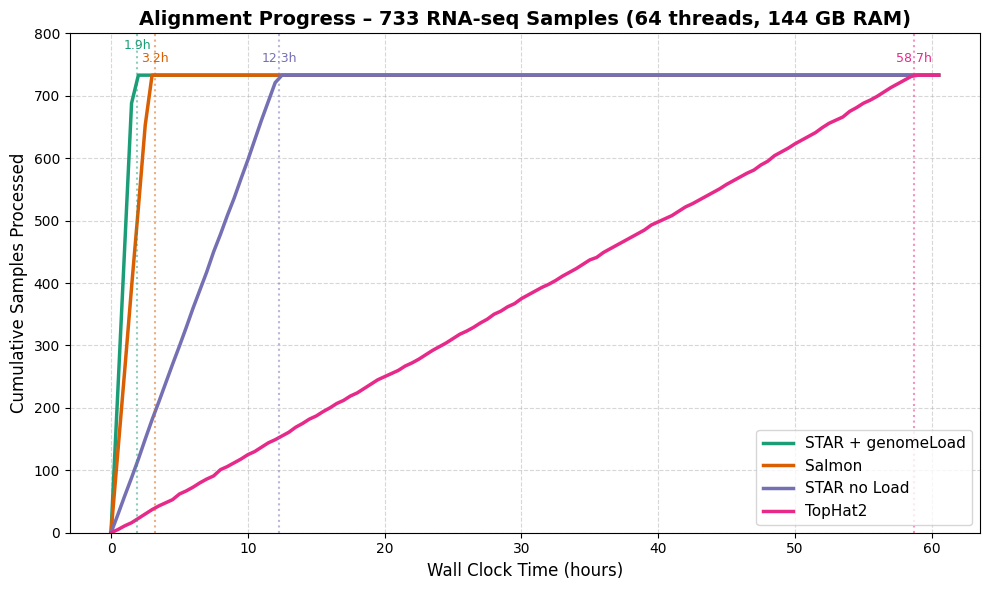

In [7]:
# Plotting
plt.figure(figsize=(10, 6))

colors = {
    'STAR_with_Load': '#1b9e77',
    'Salmon':         '#d95f02',
    'STAR_no_Load':   '#7570b3',
    'TopHat2':        '#e7298a',
}

column_map = {
    'STAR_with_Load': 'STAR + genomeLoad',
    'Salmon':         'Salmon',
    'STAR_no_Load':   'STAR no Load',
    'TopHat2':        'TopHat2',
}

for col, display_name in column_map.items():
    if col not in df.columns:
        print(f"Warning: Column '{col}' not found in CSV. Skipping.")
        continue
    plt.plot(df['Time_Hours'], df[col],
             label=display_name,
             color=colors[col],
             linewidth=2.5)
plt.xlabel('Wall Clock Time (hours)', fontsize=12)
plt.ylabel('Cumulative Samples Processed', fontsize=12)
plt.title('Alignment Progress – 733 RNA‑seq Samples (64 threads, 144 GB RAM)',
          fontsize=14, fontweight='bold')

completion_times = {
    'STAR_with_Load': 1.9,
    'Salmon':         3.2,
    'STAR_no_Load':   12.3,
    'TopHat2':       58.7,
}

# Stagger y-positions for labels so they don't overlap
y_positions = {
    'STAR_with_Load': 770,
    'Salmon':         750,
    'STAR_no_Load':   750,
    'TopHat2':        750,
}

for col, x in completion_times.items():
    if col in df.columns:
        plt.axvline(x=x, color=colors[col], linestyle=':', alpha=0.5)
        plt.text(x, y_positions[col], f'{x}h',
                 rotation=0, ha='center', va='bottom',
                 fontsize=9, color=colors[col])
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower right', fontsize=11)
plt.ylim(0, 800)
plt.tight_layout()

# Save and show
plt.savefig(output_png, dpi=300, bbox_inches='tight')
print(f"Plot saved to '{output_png}'")
plt.show()
